### import libraries

In [1]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

initializing ocelot...


### Transmission

In [2]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

### reading and plotting

In [3]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [4]:
Tshow_min = 0.15#0.4
Tshow_max = 0.5
w_show = 15
w_show_min = -w_show
w_show_max = w_show

In [5]:
data_path = "../data/intensity_sweep_2_level_fix_2"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

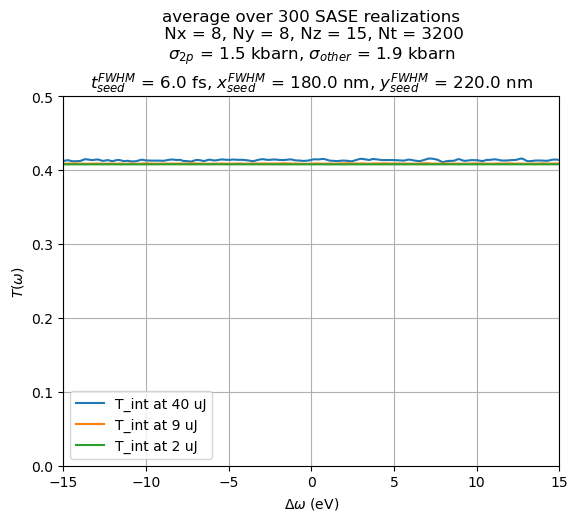

In [6]:
plt.figure()

str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
str_pars_cross_section = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' 
str_pars_seed = r'$t_{seed}^{FWHM}$ = ' f'{seed_duration_FWHM_t:.1f}' +' fs' + \
r', $x_{seed}^{FWHM}$ = ' f'{seed_width_FWHM_x:.1f}' +' nm' + \
r', $y_{seed}^{FWHM}$ = ' f'{seed_width_FWHM_y:.1f}' +' nm'

plt.title('average over ' + str(num_files) + ' SASE realizations' + '\n'
+ str_pars_grid + '\n' + str_pars_cross_section + '\n' + str_pars_seed
 )          

E_seed_values = list(sorted_accumulated_arrays.keys())
norm = plt.matplotlib.colors.LogNorm(vmin=min(E_seed_values), vmax=max(E_seed_values))
cmap = plt.matplotlib.colormaps['viridis']

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    plt.plot(womega_ar, Tint_w, label = 'T_int at '+ str(E_seed_value) + ' uJ')

plt.ylabel(r'$T(\omega$) ')
plt.xlabel(r'$\Delta\omega$ (eV)')
plt.xlim(w_show_min, w_show_max)
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/' + str_pars_grid + str_pars_cross_section + str_pars_seed + '.pdf')
plt.show()

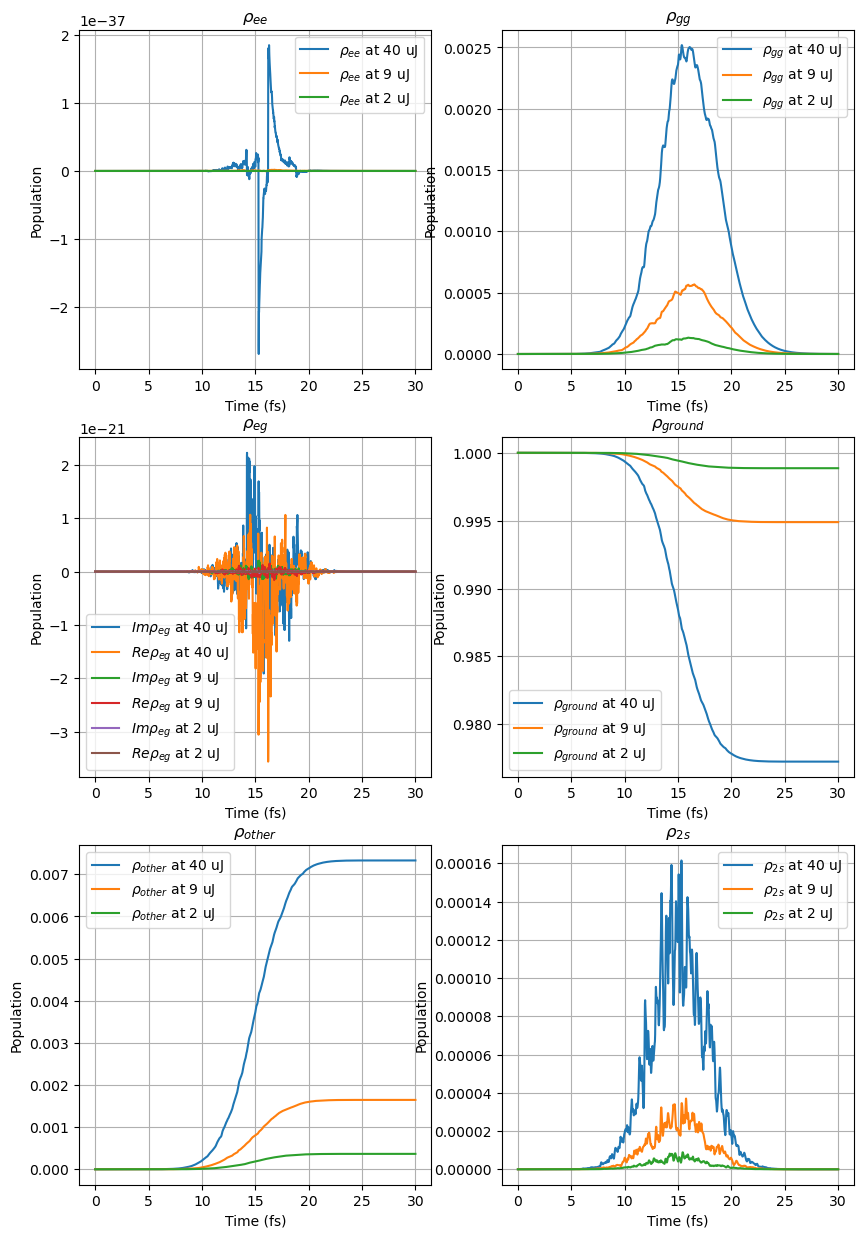

In [7]:
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

max_ee = []
max_gg = []

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    rho_ee_t_last = arrays['rho_ee_t_last']
    rho_gg_t_last = arrays['rho_gg_t_last']
    rho_eg_t_last = arrays['rho_eg_t_last']
    rho_ground_t_last = arrays['rho_ground_t_last']
    rho_other_t_last = arrays['rho_other_t_last']
    rho_2s_t_last = arrays['rho_2s_t_last']
    t_axis = arrays['t_axis']

    max_ee.append(rho_ee_t_last.max())
    max_gg.append(rho_gg_t_last.max())
    
    # Plot 2x2 grid of subplots, for example, plotting rho_ee, rho_gg, rho_eg, and rho_ground
    axs[0, 0].plot(t_axis, rho_ee_t_last, label=rf'$\rho_{{ee}}$ at {E_seed_value} uJ')
    axs[0, 1].plot(t_axis, rho_gg_t_last, label=rf'$\rho_{{gg}}$ at {E_seed_value} uJ')
    axs[1, 0].plot(t_axis, np.imag(rho_eg_t_last), label=rf'$Im\rho_{{eg}}$ at {E_seed_value} uJ')
    axs[1, 0].plot(t_axis, np.real(rho_eg_t_last), label=rf'$Re\rho_{{eg}}$ at {E_seed_value} uJ')
    axs[1, 1].plot(t_axis, rho_ground_t_last, label=rf'$\rho_{{ground}}$ at {E_seed_value} uJ')
    axs[2, 0].plot(t_axis, rho_other_t_last, label=rf'$\rho_{{other}}$ at {E_seed_value} uJ')
    axs[2, 1].plot(t_axis, rho_2s_t_last, label=rf'$\rho_{{2s}}$ at {E_seed_value} uJ')

# Set titles and labels for each subplot
axs[0, 0].set_title(r'$\rho_{ee}$')
axs[0, 1].set_title(r'$\rho_{gg}$')
axs[1, 0].set_title(r'$\rho_{eg}$')
axs[1, 1].set_title(r'$\rho_{ground}$')
axs[2, 0].set_title(r'$\rho_{other}$')
axs[2, 1].set_title(r'$\rho_{2s}$')

# Set x and y labels for each subplot
for ax in axs.flat:
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Population')
    ax.legend()
    ax.grid(True)

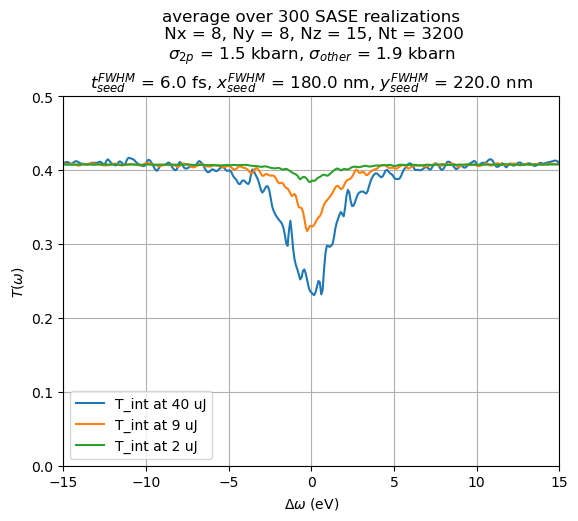

In [16]:
data_path = "../data/intensity_sweep_normal"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

plt.figure()

str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
str_pars_cross_section = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' 
str_pars_seed = r'$t_{seed}^{FWHM}$ = ' f'{seed_duration_FWHM_t:.1f}' +' fs' + \
r', $x_{seed}^{FWHM}$ = ' f'{seed_width_FWHM_x:.1f}' +' nm' + \
r', $y_{seed}^{FWHM}$ = ' f'{seed_width_FWHM_y:.1f}' +' nm'

plt.title('average over ' + str(num_files) + ' SASE realizations' + '\n'
+ str_pars_grid + '\n' + str_pars_cross_section + '\n' + str_pars_seed
 )          

E_seed_values = list(sorted_accumulated_arrays.keys())
norm = plt.matplotlib.colors.LogNorm(vmin=min(E_seed_values), vmax=max(E_seed_values))
cmap = plt.matplotlib.colormaps['viridis']

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']

    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    plt.plot(womega_ar, Tint_w, label = 'T_int at '+ str(E_seed_value) + ' uJ')

plt.ylabel(r'$T(\omega$) ')
plt.xlabel(r'$\Delta\omega$ (eV)')
plt.xlim(w_show_min, w_show_max)
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/' + str_pars_grid + str_pars_cross_section + str_pars_seed + '.pdf')
plt.show()

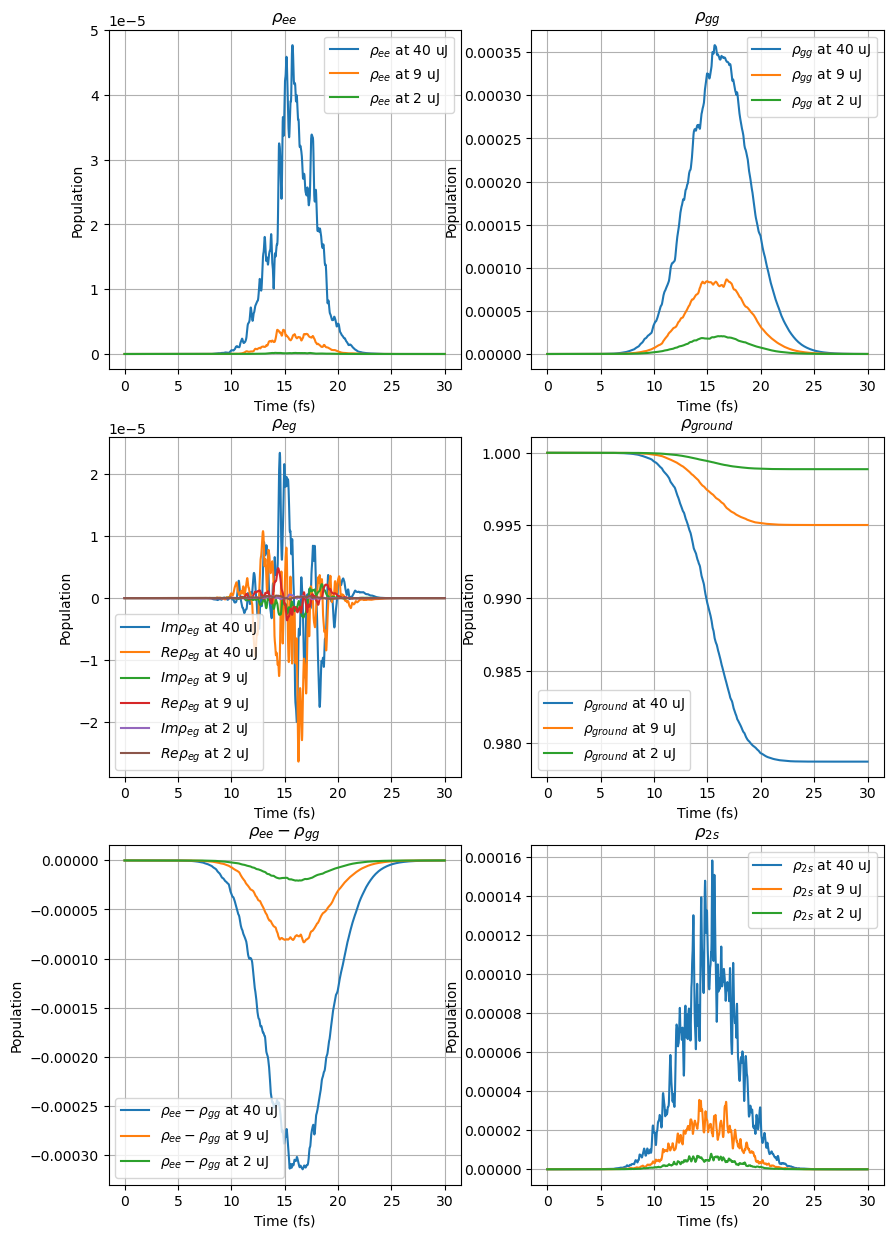

In [19]:
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

max_ee = []
max_gg = []

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    rho_ee_t_last = arrays['rho_ee_t_last']
    rho_gg_t_last = arrays['rho_gg_t_last']
    rho_eg_t_last = arrays['rho_eg_t_last']
    rho_ground_t_last = arrays['rho_ground_t_last']
    rho_other_t_last = arrays['rho_other_t_last']
    rho_2s_t_last = arrays['rho_2s_t_last']
    t_axis = arrays['t_axis']

    max_ee.append(rho_ee_t_last.max())
    max_gg.append(rho_gg_t_last.max())
    
    # Plot 2x2 grid of subplots, for example, plotting rho_ee, rho_gg, rho_eg, and rho_ground
    axs[0, 0].plot(t_axis, rho_ee_t_last, label=rf'$\rho_{{ee}}$ at {E_seed_value} uJ')
    axs[0, 1].plot(t_axis, rho_gg_t_last, label=rf'$\rho_{{gg}}$ at {E_seed_value} uJ')
    axs[1, 0].plot(t_axis, np.imag(rho_eg_t_last), label=rf'$Im\rho_{{eg}}$ at {E_seed_value} uJ')
    axs[1, 0].plot(t_axis, np.real(rho_eg_t_last), label=rf'$Re\rho_{{eg}}$ at {E_seed_value} uJ')
    axs[1, 1].plot(t_axis, rho_ground_t_last, label=rf'$\rho_{{ground}}$ at {E_seed_value} uJ')
    axs[2, 0].plot(t_axis, rho_ee_t_last - rho_gg_t_last, label=rf'$\rho_{{ee}} - \rho_{{gg}}$ at {E_seed_value} uJ')
    axs[2, 1].plot(t_axis, rho_2s_t_last, label=rf'$\rho_{{2s}}$ at {E_seed_value} uJ')

# Set titles and labels for each subplot
axs[0, 0].set_title(r'$\rho_{ee}$')
axs[0, 1].set_title(r'$\rho_{gg}$')
axs[1, 0].set_title(r'$\rho_{eg}$')
axs[1, 1].set_title(r'$\rho_{ground}$')
axs[2, 0].set_title(r'$\rho_{ee} - \rho_{gg}$')
axs[2, 1].set_title(r'$\rho_{2s}$')

# Set x and y labels for each subplot
for ax in axs.flat:
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Population')
    ax.legend()
    ax.grid(True)

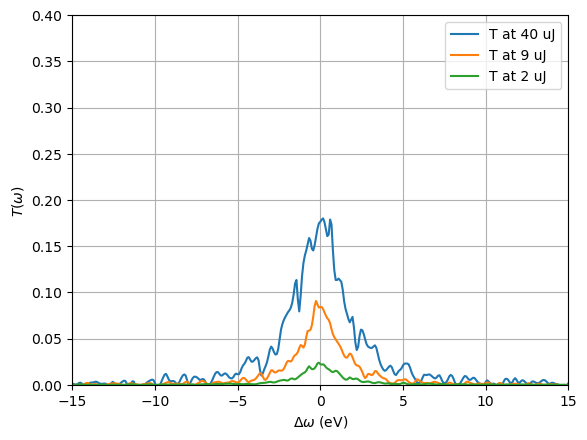

In [10]:
plt.figure()


for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    I_int_thy_w_last = I_int_thy_w_last + 0.00001 * max(I_int_thy_w_last)
    I_int_thy_w_0 = I_int_thy_w_0 + 0.00001 * max(I_int_thy_w_0)
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    mask = (womega_ar > -15) & (womega_ar < 15)
        
    n_edge = 10
    T_base = 0.5 * (
        np.mean(Tint_w[mask][:n_edge]) +
        np.mean(Tint_w[mask][-n_edge:])
    )

    dip = T_base - Tint_w
    
    plt.plot(womega_ar, dip, label = 'T at '+ str(E_seed_value) + ' uJ')
    
plt.ylabel(r'$T(\omega$) ')
plt.xlabel(r'$\Delta\omega$ (eV)')
plt.xlim(-15, 15)
plt.ylim(0, 0.4)
plt.legend()
plt.grid(True)
plt.show()

In [11]:
min_T = []
area_T = []
FWHM_T = []

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    I_int_thy_w_last = I_int_thy_w_last + 0.00001 * max(I_int_thy_w_last)
    I_int_thy_w_0 = I_int_thy_w_0 + 0.00001 * max(I_int_thy_w_0)
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    mask = (womega_ar > -15) & (womega_ar < 15)
    
    min_T.append(np.min(Tint_w[mask]))
    
    n_edge = 10
    T_base = 0.5 * (
        np.mean(Tint_w[mask][:n_edge]) +
        np.mean(Tint_w[mask][-n_edge:])
    )

    dip = T_base - Tint_w[mask]

    area_T.append(np.trapz(dip))

    FWHM_T.append(tools.find_fwhm(womega_ar[mask], dip))

    rho_ee_t_last = arrays['rho_ee_t_last']

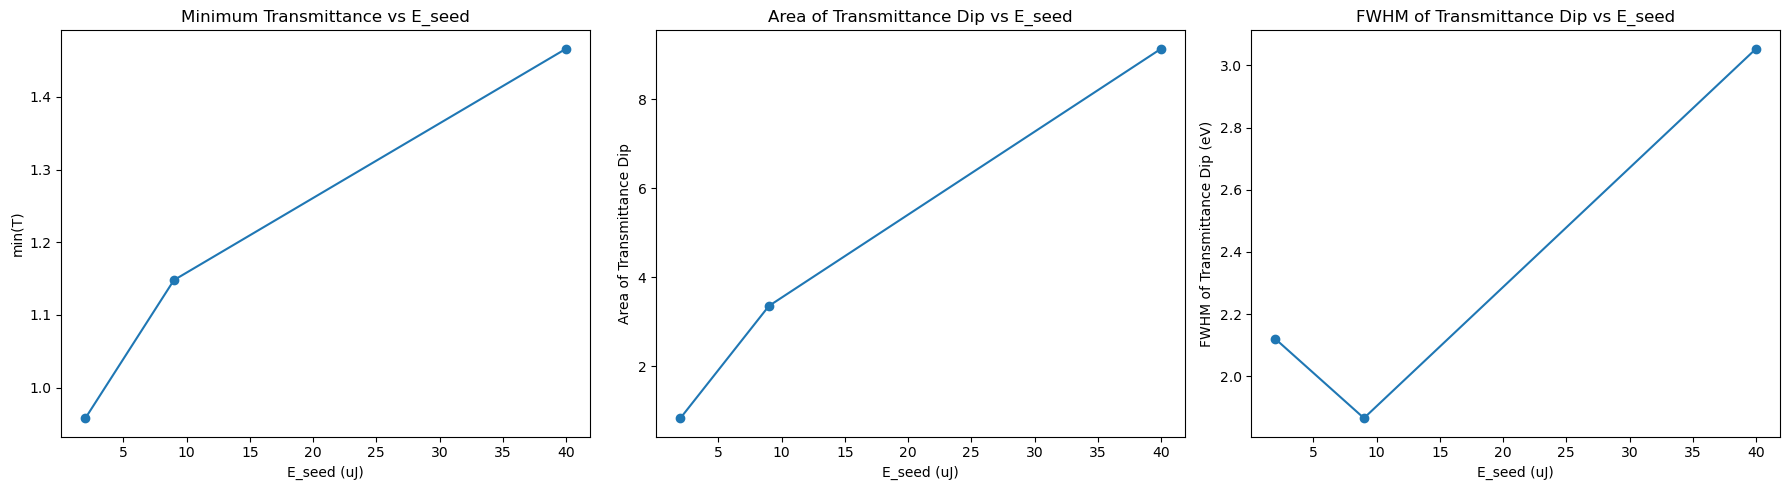

In [12]:
# Plot min_T, area_T, and FWHM_T as functions of E_seed_values in 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(E_seed_values, -np.log(min_T), marker='o')
axs[0].set_xlabel('E_seed (uJ)')
axs[0].set_ylabel('min(T)')
axs[0].set_title('Minimum Transmittance vs E_seed')

axs[1].plot(E_seed_values, area_T, marker='o')
axs[1].set_xlabel('E_seed (uJ)')
axs[1].set_ylabel('Area of Transmittance Dip')
axs[1].set_title('Area of Transmittance Dip vs E_seed')

axs[2].plot(E_seed_values, FWHM_T, marker='o')
axs[2].set_xlabel('E_seed (uJ)')
axs[2].set_ylabel('FWHM of Transmittance Dip (eV)')
axs[2].set_title('FWHM of Transmittance Dip vs E_seed')

plt.tight_layout()
plt.savefig(figs_path + '/transmittance_metrics_vs_E_seed.pdf')
plt.show()

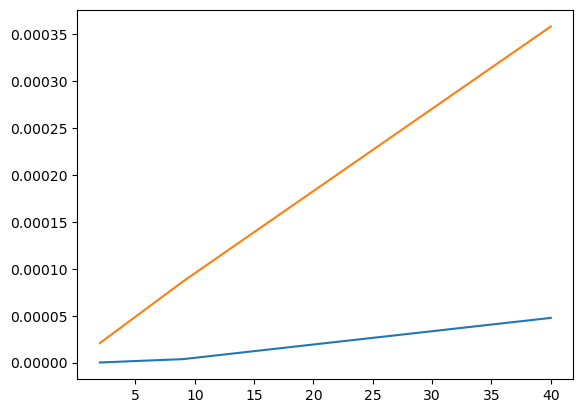

In [13]:
plt.plot(E_seed_values, max_ee, label=r"Maximum $\rho_{ee}$")
plt.plot(E_seed_values, max_gg, label=r"Maximum $\rho_{gg}$")
